#SplitSmart AC Unit ETL — Room A200
 Dataset: SplitSmart Open Dataset, BITS Pilani Goa Campus, 2019–2023
 Units: A200AC01, A200AC02, A200AC03
 Goal: Clean sensor data for AC cooling performance analysis (best/worst case)

 Columns dropped: _id, _updated, _created, _etag (metadata only)
 Note: _updated vs _created diff could monitor IoT pipeline latency — left for infra team

 Columns NOT cleaned:
 - unit_consumption: hardware-computed kWh, cannot recalculate. NaN left as-is.
 - room_temp: no anomalies found. Low readings (~16C) confirmed real (AC running).
 - Humidity: no cleaning applied.

 For downstream teams:
 - current_flag column added: standby / normal / high_load / overload / sensor_error
 - sensor_error (>35A) records are DROPPED
 - overload (25~35A) records are KEPT for Step 5 Recommendation
 - AC02 PF was negative during working periods (CT sensor wired in reverse) — fixed by abs()

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


AC01="https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis/refs/heads/main/Original%20dirty%20data%20and%20matadata/dataA200AC01.csv"
AC02='https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis/refs/heads/main/Original%20dirty%20data%20and%20matadata/dataA200AC02.csv'
AC03='https://raw.githubusercontent.com/Nils0217/Air-Conditioner-performance-analysis/refs/heads/main/Original%20dirty%20data%20and%20matadata/dataA200AC03.csv'

AC01=pd.read_csv(AC01)
AC02=pd.read_csv(AC02)
AC03=pd.read_csv(AC03)

In [41]:
AC01.info()
AC02.info()
AC03.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210740 entries, 0 to 210739
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   _id               210740 non-null  object 
 1   Time_Stamp        210740 non-null  object 
 2   Device_ID         210740 non-null  object 
 3   Current           210740 non-null  float64
 4   voltage           210740 non-null  float64
 5   Power_Factor      210740 non-null  float64
 6   Real_Power        0 non-null       float64
 7   room_temp         210740 non-null  float64
 8   External_temp     210740 non-null  float64
 9   Humidity          210740 non-null  float64
 10  unit_consumption  116099 non-null  float64
 11  _updated          210740 non-null  object 
 12  _created          210740 non-null  object 
 13  _etag             210740 non-null  object 
dtypes: float64(8), object(6)
memory usage: 22.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154522 entries, 0 

In [42]:
AC01.describe()

,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption
count,210740.00,210740.00,210740.00,0.00,210740.00,210740.00,210740.00,116099.00
mean,14.18,237.57,0.72,NaN,20.87,42.51,55.97,3.32
std,8.18,5.29,1.64,NaN,1.22,84.19,5.78,2.05
min,0.66,107.20,-730.00,NaN,15.58,0.00,48.37,0.14
25%,1.03,233.48,0.11,NaN,20.14,0.00,53.27,0.23
50%,18.34,239.14,0.97,NaN,20.39,25.46,53.41,4.42
75%,19.68,241.80,0.98,NaN,21.21,29.06,56.62,4.83
max,32.27,251.80,0.99,NaN,29.47,308.15,86.89,7.34


In [43]:
AC02.describe()

,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption
count,154522.00,154522.00,154522.00,0.00,154522.00,154522.00,154522.00,127971.00
mean,8.05,240.96,-0.24,NaN,25.92,21.52,49.57,2.21
std,9.04,8.95,0.54,NaN,2.18,12.36,4.69,2.26
min,0.65,186.04,-0.99,NaN,18.28,0.00,40.48,0.15
25%,0.91,239.27,-0.97,NaN,25.16,23.66,46.42,0.22
50%,1.01,242.23,0.04,NaN,25.97,26.75,48.58,0.25
75%,19.42,246.39,0.09,NaN,27.04,29.04,51.11,4.79
max,26.80,260.74,8.00,NaN,32.65,39.39,70.47,6.50


In [44]:
AC03.describe()

,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption
count,144769.00,144769.00,144769.00,0.00,144769.00,144769.00,144769.00,92011.00
mean,13.85,242.17,0.49,NaN,24.09,30.36,53.99,3.13
std,9.25,4.64,0.39,NaN,2.52,60.83,6.44,2.29
min,0.55,216.40,-0.98,NaN,15.80,0.00,41.92,0.19
25%,2.25,239.97,0.20,NaN,22.76,0.00,49.82,0.55
50%,19.86,241.88,0.33,NaN,23.87,25.69,52.91,4.73
75%,21.35,244.56,0.97,NaN,25.94,28.43,55.43,5.23
max,80.87,259.68,9.00,NaN,30.68,308.15,80.21,19.56


# Pre-concat fix: AC02 Power Factor
 Problem: AC02 working current (15~22A) shows PF = -0.97/-0.98 consistently

 Cause: CT sensor wired in reverse — systematic error, not random noise

 Fix: abs() applied to AC02 only, BEFORE concat to avoid affecting AC01/AC03

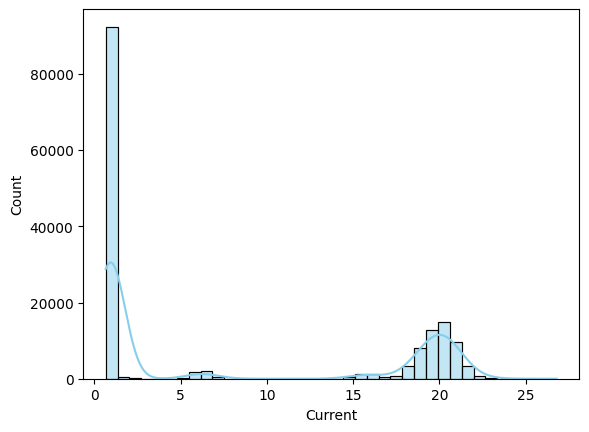

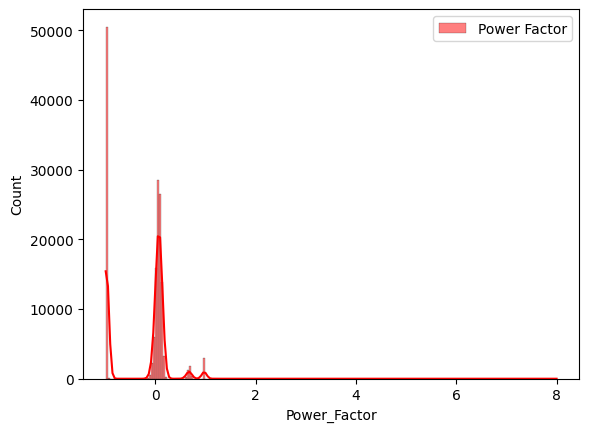

In [45]:
# Plotting 'Current' in blue
sns.histplot(AC02['Current'], color="skyblue", label="Current", kde=True, alpha=0.5)
plt.show()
# Plotting 'Power_Factor' in red on the same axes
sns.histplot(AC02['Power_Factor'], color="red", label="Power Factor", kde=True, alpha=0.5)

# Display the legend to distinguish the two variables
plt.legend()
plt.show()

In [46]:
#Checking normal unit working current
filtered_AC02 = AC02[(AC02['Current'] > 5) & (AC02['Current'] < 22)]
PA = filtered_AC02.groupby(['Device_ID', 'Power_Factor','Current']).size().reset_index(name='count')
PA.sort_values(by='count',ascending=False,inplace=True)
print(PA.head(5))
print(f'total working current:{len(filtered_AC02)}')

    Device_ID  Power_Factor  Current  count
676  A200AC02         -0.98    20.44    159
660  A200AC02         -0.98    20.32    158
652  A200AC02         -0.98    20.26    154
644  A200AC02         -0.98    20.19    150
659  A200AC02         -0.98    20.31    148
total working current:60608


In [47]:
# Take absolute value of AC02 working period PF
# abs(-0.98) = 0.98, which is a realistic high-efficiency compressor value
AC02.loc[AC02['Power_Factor'] < 0, 'Power_Factor'] = AC02['Power_Factor'].abs()

#Data Concat and Highend data view

In [48]:
df=pd.concat([AC01,AC02,AC03])
df.head(5)

,_id,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption,_updated,_created,_etag
0,ObjectId(5ebccc8de2eafcc2c358a89a),2020-05-14T04:32:28.980549+00:00,A200AC01,1.11,243.76,0.01,NaN,25.64,0.00,55.09,NaN,2020-05-14T04:43:57.000Z,2020-05-14T04:43:57.000Z,7026581cdde5219209de06cf60a63ebfd3e39ceb
1,ObjectId(5ebccd0ae2eafcc2c358a89d),2020-05-14T04:34:29.791752+00:00,A200AC01,1.22,239.75,-0.00,NaN,25.86,0.00,55.21,NaN,2020-05-14T04:46:02.000Z,2020-05-14T04:46:02.000Z,920edc93f184aa9b75aa8944ef6ec2021e9e61f7
2,ObjectId(5ebcd850e2eafcc2c358a8bf),2020-05-14T05:30:53.180777+00:00,A200AC01,20.45,240.46,0.97,NaN,25.22,0.00,55.47,NaN,2020-05-14T05:34:08.000Z,2020-05-14T05:34:08.000Z,18970c04a7441f63045f2d68076233474f27819f
3,ObjectId(5ebcd8cce2eafcc2c358a8c0),2020-05-14T05:32:54.053331+00:00,A200AC01,20.21,240.26,0.97,NaN,25.06,0.00,55.64,NaN,2020-05-14T05:36:12.000Z,2020-05-14T05:36:12.000Z,354300145f8ae4ec2f966c84adc60923c3ee6c59
4,ObjectId(5ebcd941e2eafcc2c358a8c4),2020-05-14T05:34:54.907238+00:00,A200AC01,20.05,241.16,0.97,NaN,25.00,0.00,55.61,NaN,2020-05-14T05:38:09.000Z,2020-05-14T05:38:09.000Z,bbba3cfc4ae106c366f55605c1c362a23c1de2d4


In [49]:
# IoT sensors can occasionally emit duplicate records
df.drop_duplicates(inplace=True)

In [50]:
# _id, _etag: database identifiers, no analytical value
# _updated, _created: IoT pipeline timestamps — infra team can use for latency monitoring
df.drop(['_id','_updated',	'_created',	'_etag'], axis =1,inplace=True)
df.head(5)

,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption
0,2020-05-14T04:32:28.980549+00:00,A200AC01,1.11,243.76,0.01,NaN,25.64,0.00,55.09,NaN
1,2020-05-14T04:34:29.791752+00:00,A200AC01,1.22,239.75,-0.00,NaN,25.86,0.00,55.21,NaN
2,2020-05-14T05:30:53.180777+00:00,A200AC01,20.45,240.46,0.97,NaN,25.22,0.00,55.47,NaN
3,2020-05-14T05:32:54.053331+00:00,A200AC01,20.21,240.26,0.97,NaN,25.06,0.00,55.64,NaN
4,2020-05-14T05:34:54.907238+00:00,A200AC01,20.05,241.16,0.97,NaN,25.00,0.00,55.61,NaN


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 510031 entries, 0 to 144768
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Time_Stamp        510031 non-null  object 
 1   Device_ID         510031 non-null  object 
 2   Current           510031 non-null  float64
 3   voltage           510031 non-null  float64
 4   Power_Factor      510031 non-null  float64
 5   Real_Power        0 non-null       float64
 6   room_temp         510031 non-null  float64
 7   External_temp     510031 non-null  float64
 8   Humidity          510031 non-null  float64
 9   unit_consumption  336081 non-null  float64
dtypes: float64(8), object(2)
memory usage: 42.8+ MB


In [52]:
df.describe()

,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption
count,510031.00,510031.00,510031.00,0.00,510031.00,510031.00,510031.00,336081.00
mean,12.23,239.90,0.56,NaN,23.32,32.70,53.47,2.85
std,9.18,6.78,1.11,NaN,2.92,64.07,6.28,2.25
min,0.55,107.20,-730.00,NaN,15.58,0.00,40.48,0.14
25%,0.99,237.07,0.08,NaN,20.50,0.00,49.51,0.24
50%,18.08,241.04,0.96,NaN,23.03,26.05,53.25,4.23
75%,20.20,243.44,0.97,NaN,25.77,28.88,55.23,4.91
max,80.87,260.74,9.00,NaN,32.65,308.15,86.89,19.56


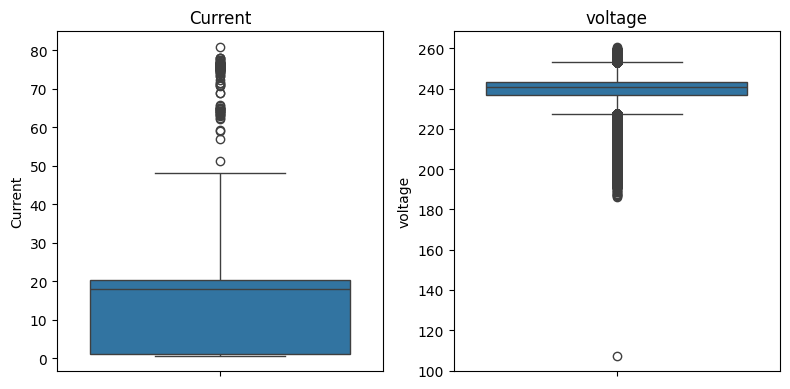

In [53]:
# Same approach for Current and Voltage
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.boxplot(data=df['Current'], ax=axes[0])
axes[0].set_title('Current')

sns.boxplot(data=df['voltage'], ax=axes[1])
axes[1].set_title('voltage')

plt.tight_layout()
plt.show()

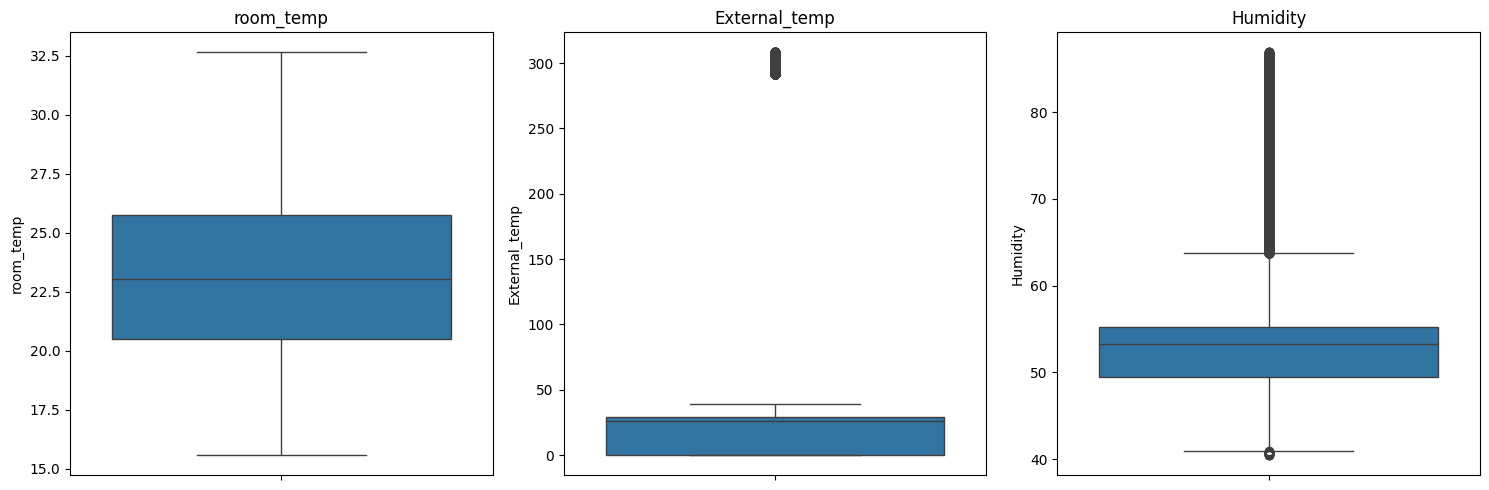

In [54]:
# Multiple columns in one row
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['room_temp', 'External_temp', 'Humidity']
for ax, col in zip(axes, cols):
    sns.boxplot(data=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

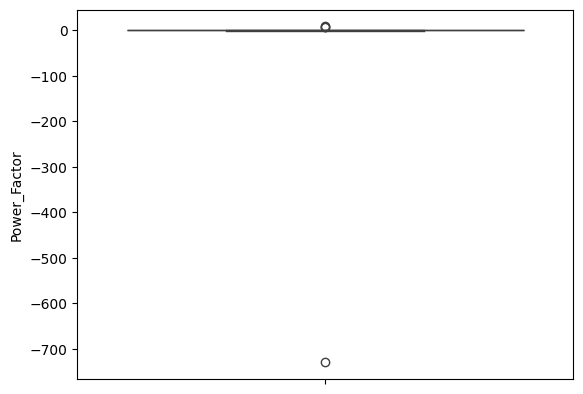

In [55]:
sns.boxplot(df['Power_Factor'])
plt.show()

# Current — Cleaning Decision

 **Physical reference from equipment nameplate:**

   **MCA (Maximum Continuous Amperage): 17–22A — normal operating range
   MOCP (Maximum Overcurrent Protection): 25–35A — circuit breaker trip point**
   

 Classification:
   
   < 5A       → standby    : control board on, compressor off. Keep.

   5 ~ 22A    → normal     : standard operation. Keep.

   22 ~ 25A   → high_load  : above MCA but within MOCP, observed in Jan winter peak. Keep.

   25 ~ 35A   → overload   : within MOCP range. Keep for Step 5 Recommendation.

   > 35A      → sensor_error: isolated spikes confirmed — adjacent records all show ~2A standby.
                              
   Cross-checked: no AC01/AC02 activity at same timestamp. DROP.

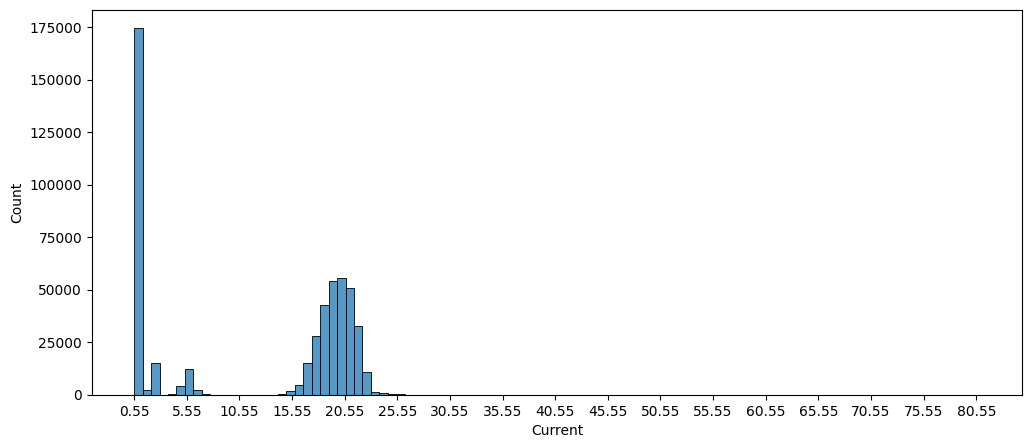

In [56]:
fig, axes = plt.subplots(figsize=(12, 5))
sns.histplot(df['Current'],bins=100)
plt.xticks(np.arange(df['Current'].min(), df['Current'].max() + 1, 5))
plt.show()

In [57]:
#Run this code to see the outliar current distribution
"""for i in range(20,81):
  a=(df['Current']>i).value_counts()
  # Check if 'True' is in the index of 'a' and its count is greater than 0
  if a.get(True) > 0:
    print(f'when Current > {i}: {a.get(True)} True values')
  else:
    print(f'when Current > {i}: No True values found')
"""

"for i in range(20,81):\n  a=(df['Current']>i).value_counts()\n  # Check if 'True' is in the index of 'a' and its count is greater than 0\n  if a.get(True) > 0:\n    print(f'when Current > {i}: {a.get(True)} True values')\n  else:\n    print(f'when Current > {i}: No True values found')\n"

In [58]:
#Run this code to see the data of current outliar
#Purpose: To distinguish if keeping but moify the outliar can bring value
"""
weird_A = df[df['Current']>35]
weird_A=weird_A.sort_values(by='Current')
weird_A.head(5)
"""

"\nweird_A = df[df['Current']>35]\nweird_A=weird_A.sort_values(by='Current')\nweird_A.head(5)\n"

In [59]:
#This step is to checking if the outlier is a spark or having relationship
#with all units
"""
# Set to date TS
df["Time_Stamp"] = pd.to_datetime(df["Time_Stamp"])

# Get the timestamp of the 80.87A anomaly in AC03
hit_time = df.loc[(df["Device_ID"] == "A200AC03") & (df["Current"] == 80.87), "Time_Stamp"].iloc[0]

# Check if AC01/AC02 had any activity within ±1 hour
window = df[
    df["Device_ID"].isin(["A200AC01", "A200AC02"]) &
    df["Time_Stamp"].between(hit_time - pd.Timedelta(hours=1), hit_time + pd.Timedelta(hours=1))
]

# Empty result confirms 80.87A is an isolated sensor glitch
print(window[["Time_Stamp", "Device_ID", "Current"]].sort_values("Time_Stamp"))

"""

'\n# Set to date TS\ndf["Time_Stamp"] = pd.to_datetime(df["Time_Stamp"])\n\n# Get the timestamp of the 80.87A anomaly in AC03\nhit_time = df.loc[(df["Device_ID"] == "A200AC03") & (df["Current"] == 80.87), "Time_Stamp"].iloc[0]\n\n# Check if AC01/AC02 had any activity within ±1 hour\nwindow = df[\n    df["Device_ID"].isin(["A200AC01", "A200AC02"]) &\n    df["Time_Stamp"].between(hit_time - pd.Timedelta(hours=1), hit_time + pd.Timedelta(hours=1))\n]\n\n# Empty result confirms 80.87A is an isolated sensor glitch\nprint(window[["Time_Stamp", "Device_ID", "Current"]].sort_values("Time_Stamp"))\n\n'

In [60]:
total = len(df)

a = (df['Current'] < 5).sum()
b = ((df['Current'] >= 5) & (df['Current'] <= 22)).sum()
c = ((df['Current'] > 22) & (df['Current'] <= 25)).sum()
d = ((df['Current'] > 25) & (df['Current'] <= 35)).sum()
e = (df['Current'] > 35).sum()

print(f'total : {total}')
print(f'a (<5A)    : {a} ({a/total:.1%})')
print(f'b (5~22A)  : {b} ({b/total:.1%})')
print(f'c (22~25A) : {c} ({c/total:.1%})')
print(f'd (25~35A) : {d} ({d/total:.1%})')
print(f'e (>35A)   : {e} ({e/total:.1%})')

total : 510031
a (<5A)    : 193296 (37.9%)
b (5~22A)  : 295680 (58.0%)
c (22~25A) : 20551 (4.0%)
d (25~35A) : 394 (0.1%)
e (>35A)   : 110 (0.0%)


**Label first, drop separately — keeps logic transparent and reversible**



In [61]:
# Cleaning current function
# Solution: layering

def clean_current(df):
    df = df.copy()
    df['current_flag'] = 'normal'

    # Standby state (Reserved, marked)）
    df.loc[df['Current'] < 5, 'current_flag'] = 'standby'

    # 22~25A: Reserved, marked for warning (high load in January may be real)
    df.loc[(df['Current'] > 22) & (df['Current'] <= 25), 'current_flag'] = 'high_load'

    # 25~35A: MOCP zone, marked for overload
    df.loc[(df['Current'] > 25) & (df['Current'] <= 35), 'current_flag'] = 'overload'

    # >35A: Three-phase missummation, directly marked for discard
    df.loc[df['Current'] > 35, 'current_flag'] = 'sensor_error'

    return df

In [62]:
df = clean_current(df)

In [63]:
# Only drop sensor_error. overload (25~35A)
df[df['current_flag'] != 'sensor_error']

,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption,current_flag
0,2020-05-14T04:32:28.980549+00:00,A200AC01,1.11,243.76,0.01,NaN,25.64,0.00,55.09,NaN,standby
1,2020-05-14T04:34:29.791752+00:00,A200AC01,1.22,239.75,-0.00,NaN,25.86,0.00,55.21,NaN,standby
2,2020-05-14T05:30:53.180777+00:00,A200AC01,20.45,240.46,0.97,NaN,25.22,0.00,55.47,NaN,normal
3,2020-05-14T05:32:54.053331+00:00,A200AC01,20.21,240.26,0.97,NaN,25.06,0.00,55.64,NaN,normal
4,2020-05-14T05:34:54.907238+00:00,A200AC01,20.05,241.16,0.97,NaN,25.00,0.00,55.61,NaN,normal
...,...,...,...,...,...,...,...,...,...,...,...
144764,2021-08-25T04:01:29.338077+00:00,A200AC03,5.74,240.55,0.33,NaN,24.84,26.89,53.72,1.40,normal
144765,2021-08-25T04:03:30.471866+00:00,A200AC03,5.72,239.24,0.32,NaN,24.84,26.82,53.72,1.39,normal
144766,2021-08-25T04:05:31.054618+00:00,A200AC03,5.41,238.19,0.34,NaN,24.84,26.81,53.76,1.31,normal
144767,2021-08-25T04:07:31.898214+00:00,A200AC03,5.80,240.50,0.35,NaN,24.85,26.82,53.79,1.41,normal


# Voltage — Cleaning Decision
 India nominal supply: 230V ±6% → 216~244V compliant

 185~216V: real grid undervoltage events — retain as worst-case stress scenario

 ~107V: physically impossible for AC operation — drop


 Using 3×IQR (not 1.5×IQR) to avoid dropping legitimate low-voltage records
 1.5×IQR lower bound ~233V is too aggressive — removes real data
 3×IQR lower bound ~226V only removes true extremes

In [64]:
Q1 = df['voltage'].quantile(0.25)
Q3 = df['voltage'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

df = df[df['voltage'].between(lower, upper)]

# External_temp — Cleaning Decision

 Goa climate: annual daily mean ~28-29C, max ~30-34C, absolute min ~20C
 == 0 : sensor no-read, not real temperature → replace with median

 > 50 : physically impossible for Goa → replace with median

 < 20 : impossible for Goa annual climate → replace with median

 Median calculated from valid range only (20~35C) to avoid bias from anomalous values

In [65]:
df['External_temp'].describe()


,External_temp
count,503788.00
mean,33.06
std,64.31
min,0.00
25%,0.00
50%,26.09
75%,28.91
max,308.15


In [66]:
# Temperature range set to 20-35 is for reflecting Goa's condition
median_val = df.loc[df['External_temp'].between(20, 35), 'External_temp'].median()
df['External_temp'] = df['External_temp'].where(df['External_temp'].between(20, 35), median_val)

# Power Factor — Cleaning Decision

 Normal range: 0 to 1 (cannot exceed 1 physically)

 Fixes applied in order:

 1. PF = -730 (AC01)        → 0    :
 single extreme sensor error
 2. AC02 PF = 1 or 8        → 0    :
 Current < 1A standby, PF has no meaning at near-zero current
 3. AC03 PF = 8 or 9        → ÷10  :
 Current ~20A running, decimal point dropped by firmware confirmed by surrounding records showing PF ~0.18-0.21
 4. remaining negative PF   → 0    : residual noise

In [67]:
a = df['Power_Factor'].unique()
b=np.sort(a)
b

array([-7.3e+02, -9.8e-01, -9.7e-01, -9.6e-01, -4.1e-01, -1.2e-01,
       -1.1e-01, -1.0e-01, -9.0e-02, -8.0e-02, -7.0e-02, -6.0e-02,
       -5.0e-02, -4.0e-02, -3.0e-02, -2.0e-02, -1.0e-02, -0.0e+00,
        1.0e-02,  2.0e-02,  3.0e-02,  4.0e-02,  5.0e-02,  6.0e-02,
        7.0e-02,  8.0e-02,  9.0e-02,  1.0e-01,  1.1e-01,  1.2e-01,
        1.3e-01,  1.4e-01,  1.5e-01,  1.6e-01,  1.7e-01,  1.8e-01,
        1.9e-01,  2.0e-01,  2.1e-01,  2.2e-01,  2.3e-01,  2.4e-01,
        2.5e-01,  2.6e-01,  2.7e-01,  2.8e-01,  2.9e-01,  3.0e-01,
        3.1e-01,  3.2e-01,  3.3e-01,  3.4e-01,  3.5e-01,  3.6e-01,
        3.7e-01,  3.8e-01,  3.9e-01,  4.0e-01,  4.1e-01,  4.2e-01,
        4.3e-01,  4.4e-01,  4.5e-01,  4.6e-01,  4.7e-01,  4.8e-01,
        4.9e-01,  5.0e-01,  5.1e-01,  5.2e-01,  5.3e-01,  5.4e-01,
        5.5e-01,  5.6e-01,  5.7e-01,  5.8e-01,  5.9e-01,  6.0e-01,
        6.1e-01,  6.2e-01,  6.3e-01,  6.4e-01,  6.5e-01,  6.6e-01,
        6.7e-01,  6.8e-01,  6.9e-01,  7.0e-01,  7.1e-01,  7.2e

In [68]:
#Check amount of outliar
count=(df['Power_Factor']==-7.3e+02).sum()
count

np.int64(1)

In [69]:
large = df[df['Power_Factor'].isin([1, 8, 9])]
large

,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption,current_flag
18188,2020-11-04T00:58:01.151527+00:00,A200AC02,0.95,246.21,8.00,NaN,24.90,27.60,45.16,NaN,standby
25954,2020-11-16T19:43:58.564382+00:00,A200AC02,1.02,245.89,1.00,NaN,26.90,27.60,47.92,NaN,standby
14382,2020-04-17T22:27:49.034053+00:00,A200AC03,20.73,240.38,8.00,NaN,27.46,27.60,47.18,NaN,normal
14390,2020-04-17T22:50:03.594430+00:00,A200AC03,20.56,241.18,9.00,NaN,27.44,27.60,47.14,NaN,normal


In [70]:
df['Power_Factor']=df['Power_Factor'].replace(-7.3e+02,0)

# AC02：PF = 1 or 8 → set to 0, because the low current repersent the unit isn't working
df.loc[(df['Device_ID'] == 'A200AC02') & (df['Power_Factor'].isin([1, 8])), 'Power_Factor'] = 0

# AC03：PF = 8 or 9 → /10
df.loc[(df['Device_ID'] == 'A200AC03') & (df['Power_Factor'].isin([8, 9])), 'Power_Factor'] /= 10
df.head(5)

,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption,current_flag
0,2020-05-14T04:32:28.980549+00:00,A200AC01,1.11,243.76,0.01,NaN,25.64,27.60,55.09,NaN,standby
1,2020-05-14T04:34:29.791752+00:00,A200AC01,1.22,239.75,-0.00,NaN,25.86,27.60,55.21,NaN,standby
2,2020-05-14T05:30:53.180777+00:00,A200AC01,20.45,240.46,0.97,NaN,25.22,27.60,55.47,NaN,normal
3,2020-05-14T05:32:54.053331+00:00,A200AC01,20.21,240.26,0.97,NaN,25.06,27.60,55.64,NaN,normal
4,2020-05-14T05:34:54.907238+00:00,A200AC01,20.05,241.16,0.97,NaN,25.00,27.60,55.61,NaN,normal


In [71]:
# Running current with near-zero negative PF = display artifact of -0
# Use abs() instead of clipping to 0 to preserve the actual value
df['Power_Factor'] = df['Power_Factor'].abs()

# Real_Power — all NaN in original dataset, sensor did not compute it

 **Formula: Real Power (W) = Current (A) × Voltage (V) × Power Factor**

 Calculated AFTER all Current, voltage, and Power_Factor cleaning is complete

In [72]:
df['Real_Power']=df['Current']*df['voltage']*df['Power_Factor']
df.tail(5)

,Time_Stamp,Device_ID,Current,voltage,Power_Factor,Real_Power,room_temp,External_temp,Humidity,unit_consumption,current_flag
144764,2021-08-25T04:01:29.338077+00:00,A200AC03,5.74,240.55,0.33,455.65,24.84,26.89,53.72,1.40,normal
144765,2021-08-25T04:03:30.471866+00:00,A200AC03,5.72,239.24,0.32,437.90,24.84,26.82,53.72,1.39,normal
144766,2021-08-25T04:05:31.054618+00:00,A200AC03,5.41,238.19,0.34,438.13,24.84,26.81,53.76,1.31,normal
144767,2021-08-25T04:07:31.898214+00:00,A200AC03,5.80,240.50,0.35,488.21,24.85,26.82,53.79,1.41,normal
144768,2021-08-25T04:09:32.752855+00:00,A200AC03,5.65,239.86,0.30,406.56,24.85,26.67,53.83,1.37,normal


# Handoff note for
#Step 2 (analysis)
#Step 3 (BI)
#Step 4 (Data Science)


 current_flag values:

   standby      : Current < 5A, compressor off

   normal       : Current 5~22A, standard operation

   high_load    : Current 22~25A, above MCA

   overload     : Current 25~35A, within MOCP — use in Step 5 only
   
   sensor_error : Current > 35A — DROPPED, not in this dataset

 unit_consumption: NaN not imputed — use skipna=True or dropna() in analysis
 room_temp: all values valid, no cleaning applied

#Appendix


In [73]:
#Checking if all three unit work at the same date
"""

df["Time_Stamp"] = pd.to_datetime(df["Time_Stamp"])
df["date"] = df["Time_Stamp"].dt.date
df["minute"] = df["Time_Stamp"].dt.minute

# How many different unit in the same date
g = df.groupby(['date',"minute"])["Device_ID"].nunique()

# Find out all dates with 3 units working
dates_3_units = g[g == 3].index

print(dates_3_units)

"""

'\n\ndf["Time_Stamp"] = pd.to_datetime(df["Time_Stamp"])\ndf["date"] = df["Time_Stamp"].dt.date\ndf["minute"] = df["Time_Stamp"].dt.minute\n\n# How many different unit in the same date\ng = df.groupby([\'date\',"minute"])["Device_ID"].nunique()\n\n# Find out all dates with 3 units working\ndates_3_units = g[g == 3].index\n\nprint(dates_3_units)\n\n'

In [74]:
# Check: running current but PF = 0 (likely cleaning artifact)
suspicious = df[(df['Current'] > 5) & (df['Power_Factor'] == 0)]
print(f'Running but PF=0: {len(suspicious)} 筆')

Running but PF=0: 451 筆


In [75]:
print(suspicious)

                              Time_Stamp Device_ID  Current  voltage  \
146658  2021-07-16T14:02:57.676954+00:00  A200AC02     5.80   237.03   
146659  2021-07-16T14:04:58.543790+00:00  A200AC02     6.32   234.87   
146679  2021-07-16T14:51:18.645347+00:00  A200AC02     6.57   239.27   
146680  2021-07-16T14:53:19.543857+00:00  A200AC02     6.58   239.50   
146707  2021-07-16T15:51:44.983439+00:00  A200AC02     6.54   241.85   
146729  2021-07-16T16:40:05.809851+00:00  A200AC02     6.37   240.50   
146770  2021-07-16T18:08:44.249975+00:00  A200AC02     6.81   241.10   
146783  2021-07-16T18:43:02.671279+00:00  A200AC02     6.29   238.88   
146824  2021-07-16T20:09:40.100507+00:00  A200AC02     6.39   239.08   
146830  2021-07-16T20:21:45.293857+00:00  A200AC02     6.79   240.66   
146848  2021-07-16T21:00:06.842919+00:00  A200AC02     6.67   240.35   
146882  2021-07-16T22:12:33.197546+00:00  A200AC02     6.66   242.25   
146884  2021-07-16T22:20:36.701410+00:00  A200AC02     6.29   24

In [78]:
# Download CSV
"""

df.to_csv('Goa_AC_unit_performance_clean.csv', index=False, float_format='%.2f')

"""